# Irrigation Need - Project Work

## Luca Zaffaroni


In [17]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 
import seaborn as sns
import math
from matplotlib import pyplot as plt

from sklearn.preprocessing import PowerTransformer, LabelEncoder, QuantileTransformer, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import balanced_accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.svm import LinearSVC

from lightgbm import LGBMClassifier

url = './train.csv'
sep = ','
train_size = 0.85
random_state = 42
np.random.seed(random_state)
target = 'Irrigation_Need'


### 1) Dataframe inspection

In [18]:
df = pd.read_csv(url, header=0, sep=sep, index_col=0)

df.sample(5)
df.info()
df.describe()
print(f'In the database there are {df.shape[0]} rows and {df.shape[1]} columns')


<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Water_Sou

### 2) Plotting data
N.B. Pairplotting with Seaborn was not implemented due to time consuming and poor quality results

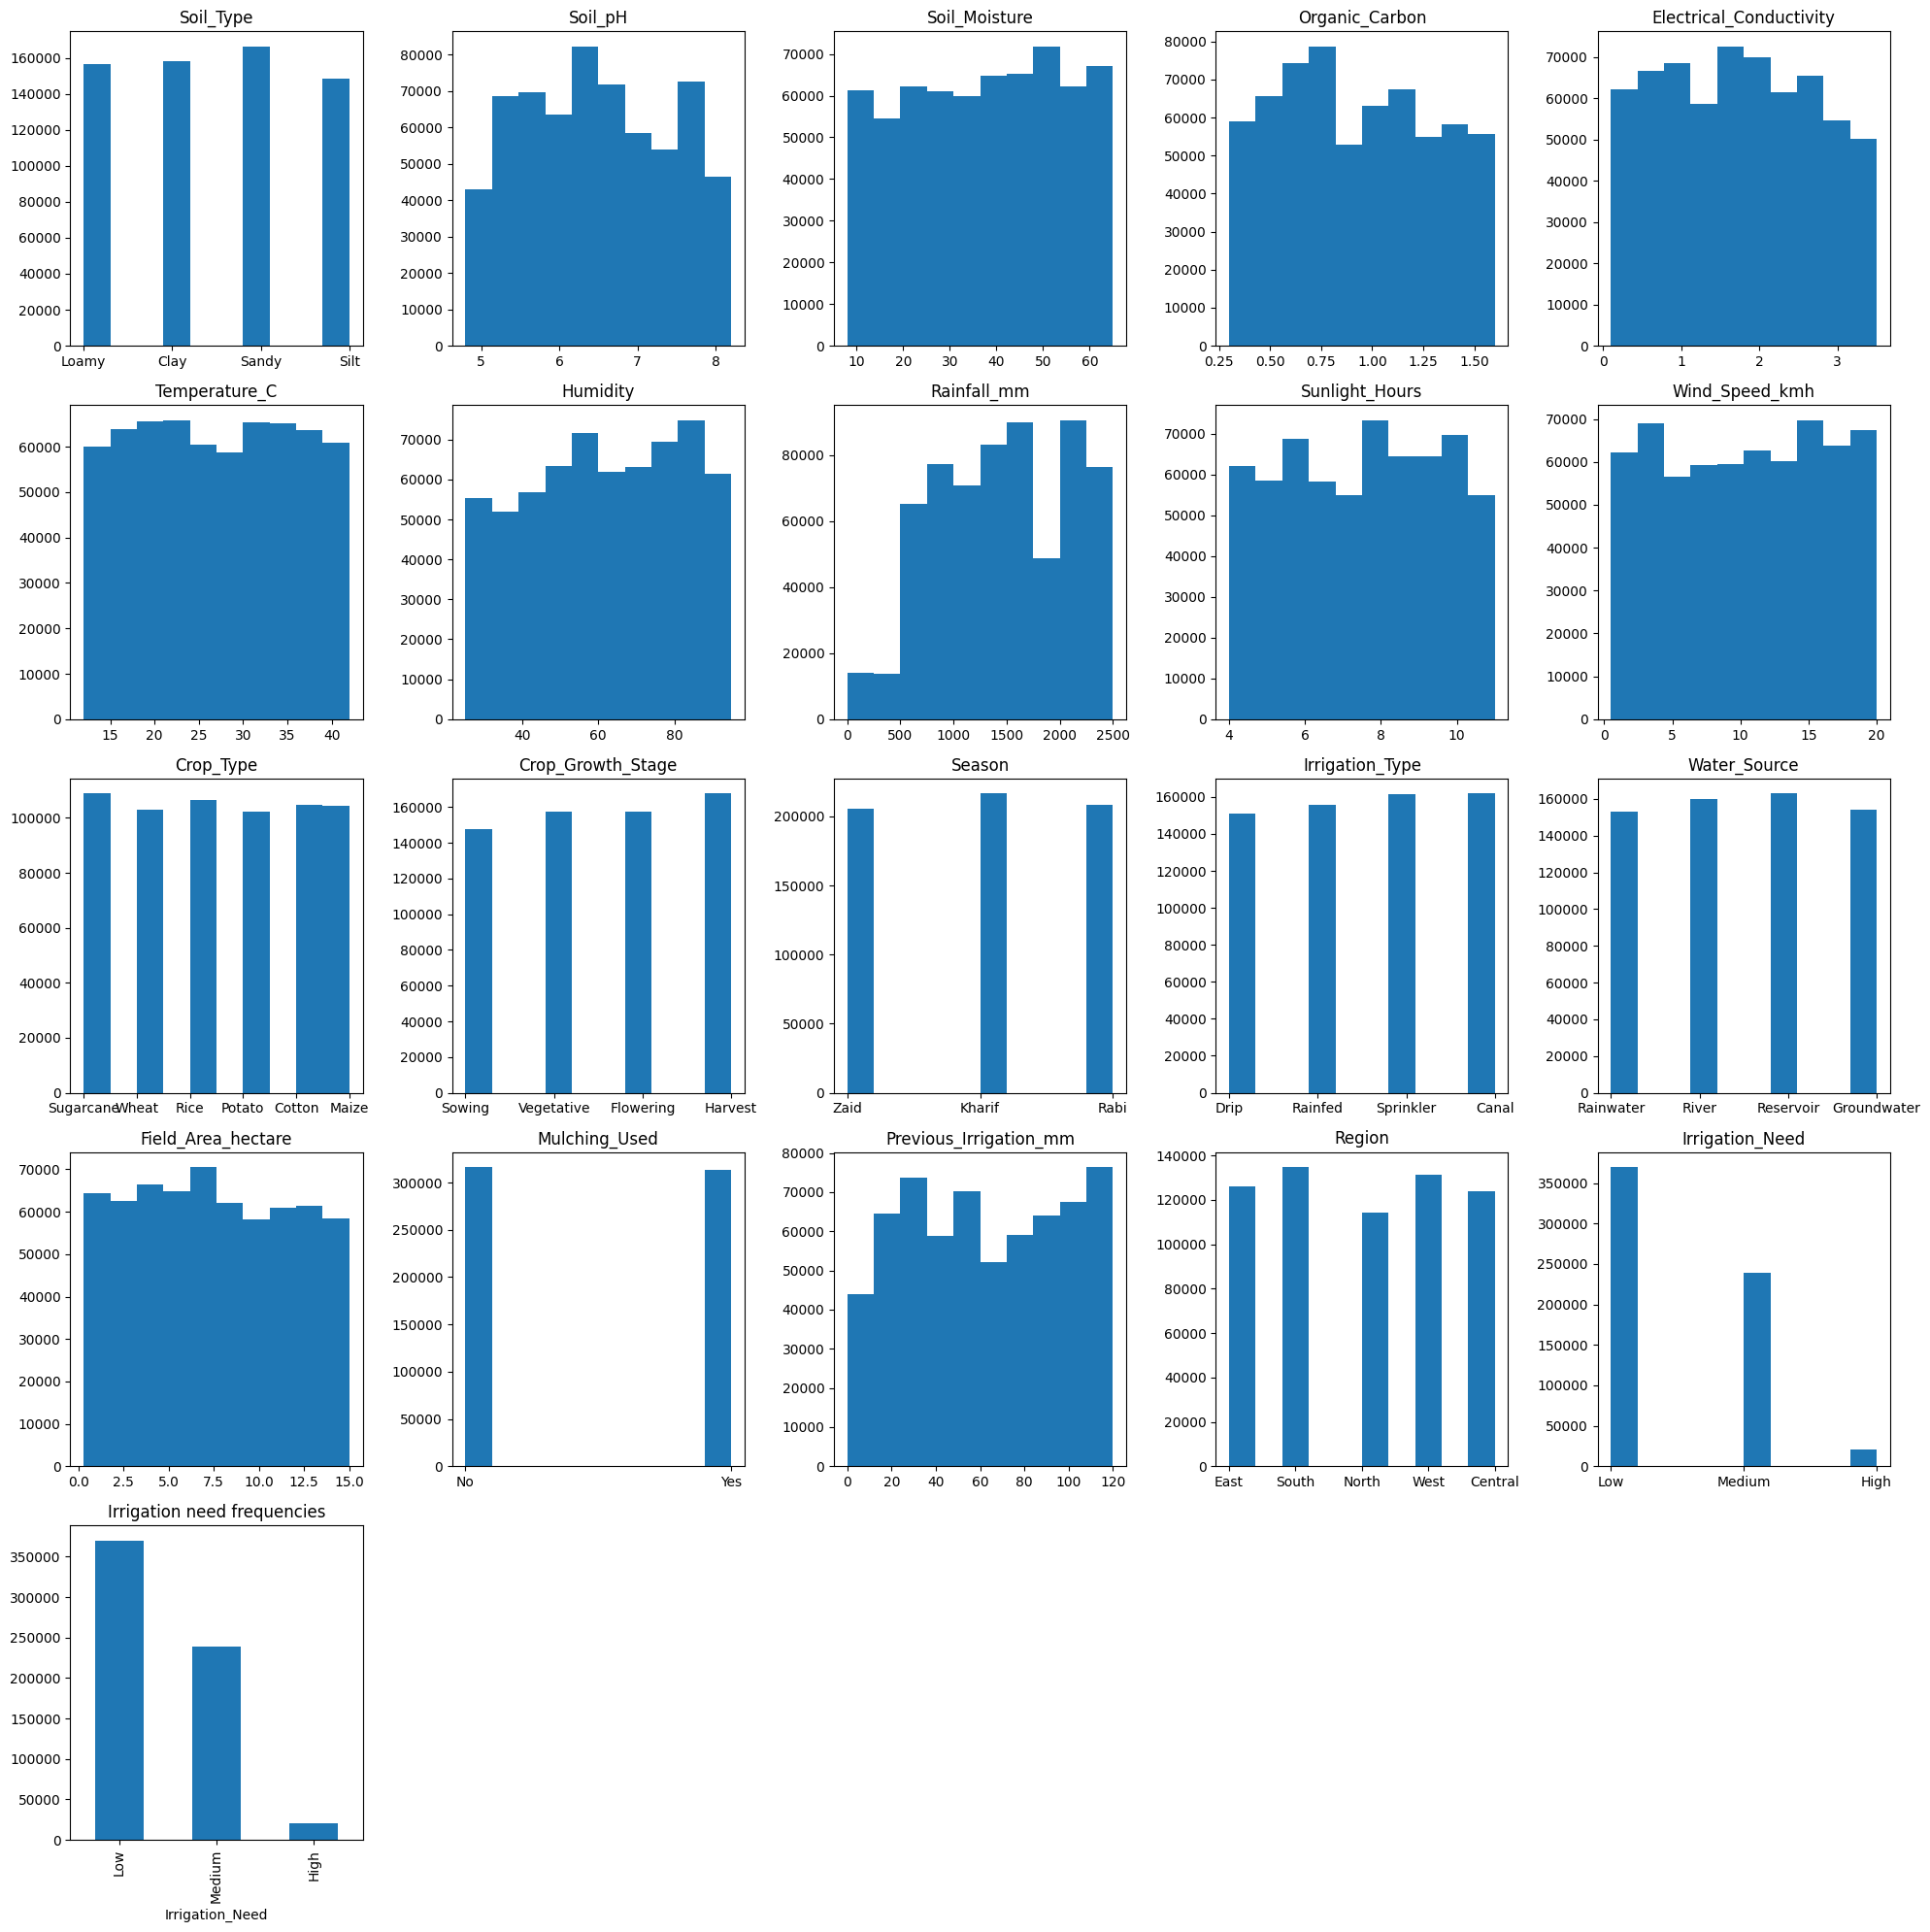

KeyboardInterrupt: 

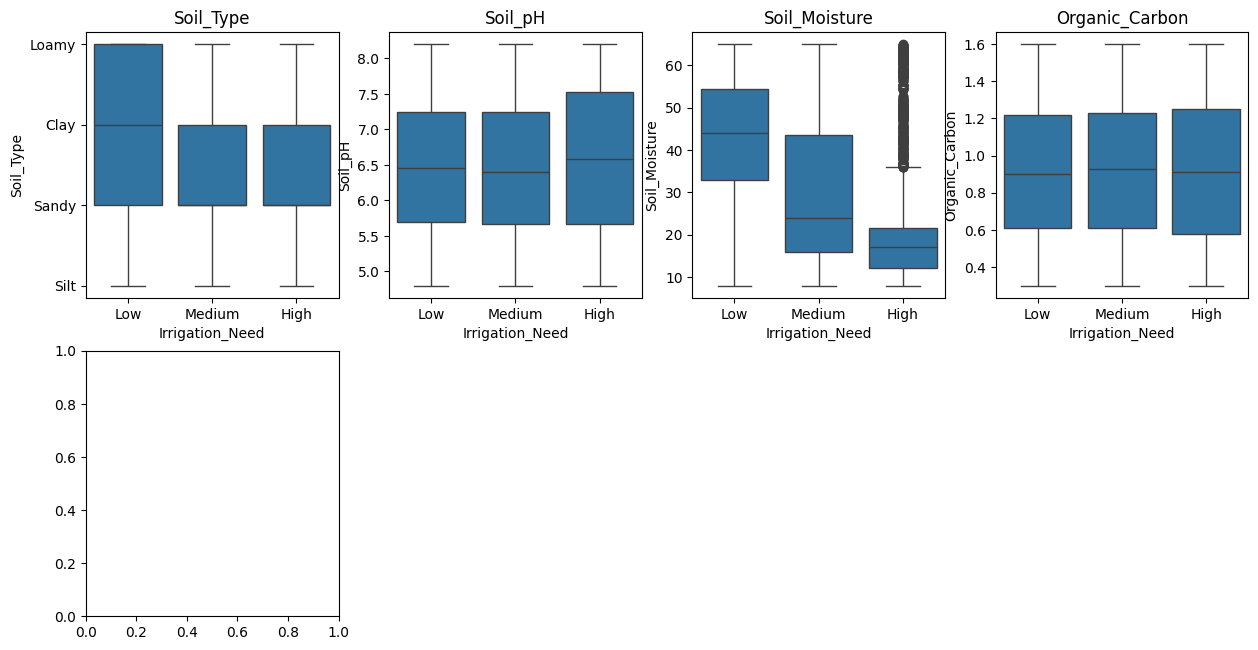

In [19]:

n_cols = len(df.columns) + 2
i = 0

rows = math.ceil(math.sqrt(n_cols))
cols = math.ceil(n_cols / rows)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
axes = axes.flatten()

for col in df.columns:
    axes[i].hist(df[col], bins=10)
    axes[i].set_title(col)
    i += 1

df[target].value_counts(sort=False).plot(kind='bar', ax=axes[i])
axes[i].set_title("Irrigation need frequencies")
i += 1

for j in range(i, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15,20))
index = 1
for col in df.columns:
    plt.subplot(5, 4, index)
    sns.boxplot(x=df[target], y=df[col])
    plt.title(col)
    index += 1

plt.tight_layout()
plt.show()


### 3) Target/features encoding and transformations

In [ ]:
le = LabelEncoder()
qt = QuantileTransformer(output_distribution="uniform", random_state=0)
pt = PowerTransformer(method='yeo-johnson')
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)


X = df.drop(target, axis=1)
#['Temperature_C'] = X['Temperature_C'].apply(lambda t: t + 273.15)
y_encoded = le.fit_transform(df[target])

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, train_size=train_size, random_state=random_state)
print(f"Before: {X_train.shape} shape examples")
print(f"Before: {X_test.shape} shape examples")
print(f"Target is divided as {y_train.shape} samples for training and {y_test.shape} samples for testing")
                            
cols_to_transform = ['Soil_Moisture','Temperature_C','Rainfall_mm','Wind_Speed_kmh',
                      'Previous_Irrigation_mm', 'Soil_pH','Organic_Carbon',
                      'Electrical_Conductivity','Humidity', 'Sunlight_Hours', 'Field_Area_hectare']

cols_to_one_hot_encode = ['Crop_Growth_Stage','Mulching_Used', 'Soil_Type', 'Crop_Type', 
                          'Season', 'Irrigation_Type', 'Water_Source', 'Region']

#Train cat. features
X_train_ohe = ohe.fit_transform(X_train[cols_to_one_hot_encode])
ohe_cols = ohe.get_feature_names_out(cols_to_one_hot_encode)
df_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)

#Test cat. features
X_test_ohe = ohe.transform(X_test[cols_to_one_hot_encode])
df_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cols, index=X_test.index)

#Train num. features
X_train_float  = X_train[cols_to_transform] 
X_train_qt = pt.fit_transform(X_train_float)
#X_train_qt = X_train_float
df_train_qt = pd.DataFrame(X_train_qt, columns=cols_to_transform, index=X_train.index)

#Test num. features
#X_test_qt = X_test[cols_to_transform]
X_test_qt = pt.transform(X_test[cols_to_transform])
df_test_qt  = pd.DataFrame(X_test_qt,  columns=cols_to_transform, index=X_test.index)

#Merging features all toghether
X_train_full = pd.concat([df_train_ohe, df_train_qt], axis=1)
X_test_full = pd.concat([df_test_ohe, df_test_qt], axis=1)

print(f"Training on {X_train_full.shape}")
print(f"Testing on {X_test_full.shape}")

Before: (535500, 19) shape examples
Before: (94500, 19) shape examples
Target is divided as (535500,) samples for training and (94500,) samples for testing
Training on (535500, 43)
Testing on (94500, 43)


### 4) Feature selection

Crop_Growth_Stage_Flowering
Crop_Growth_Stage_Harvest
Crop_Growth_Stage_Sowing
Crop_Growth_Stage_Vegetative
Mulching_Used_No
Mulching_Used_Yes
Soil_Moisture
Temperature_C
Rainfall_mm
Wind_Speed_kmh


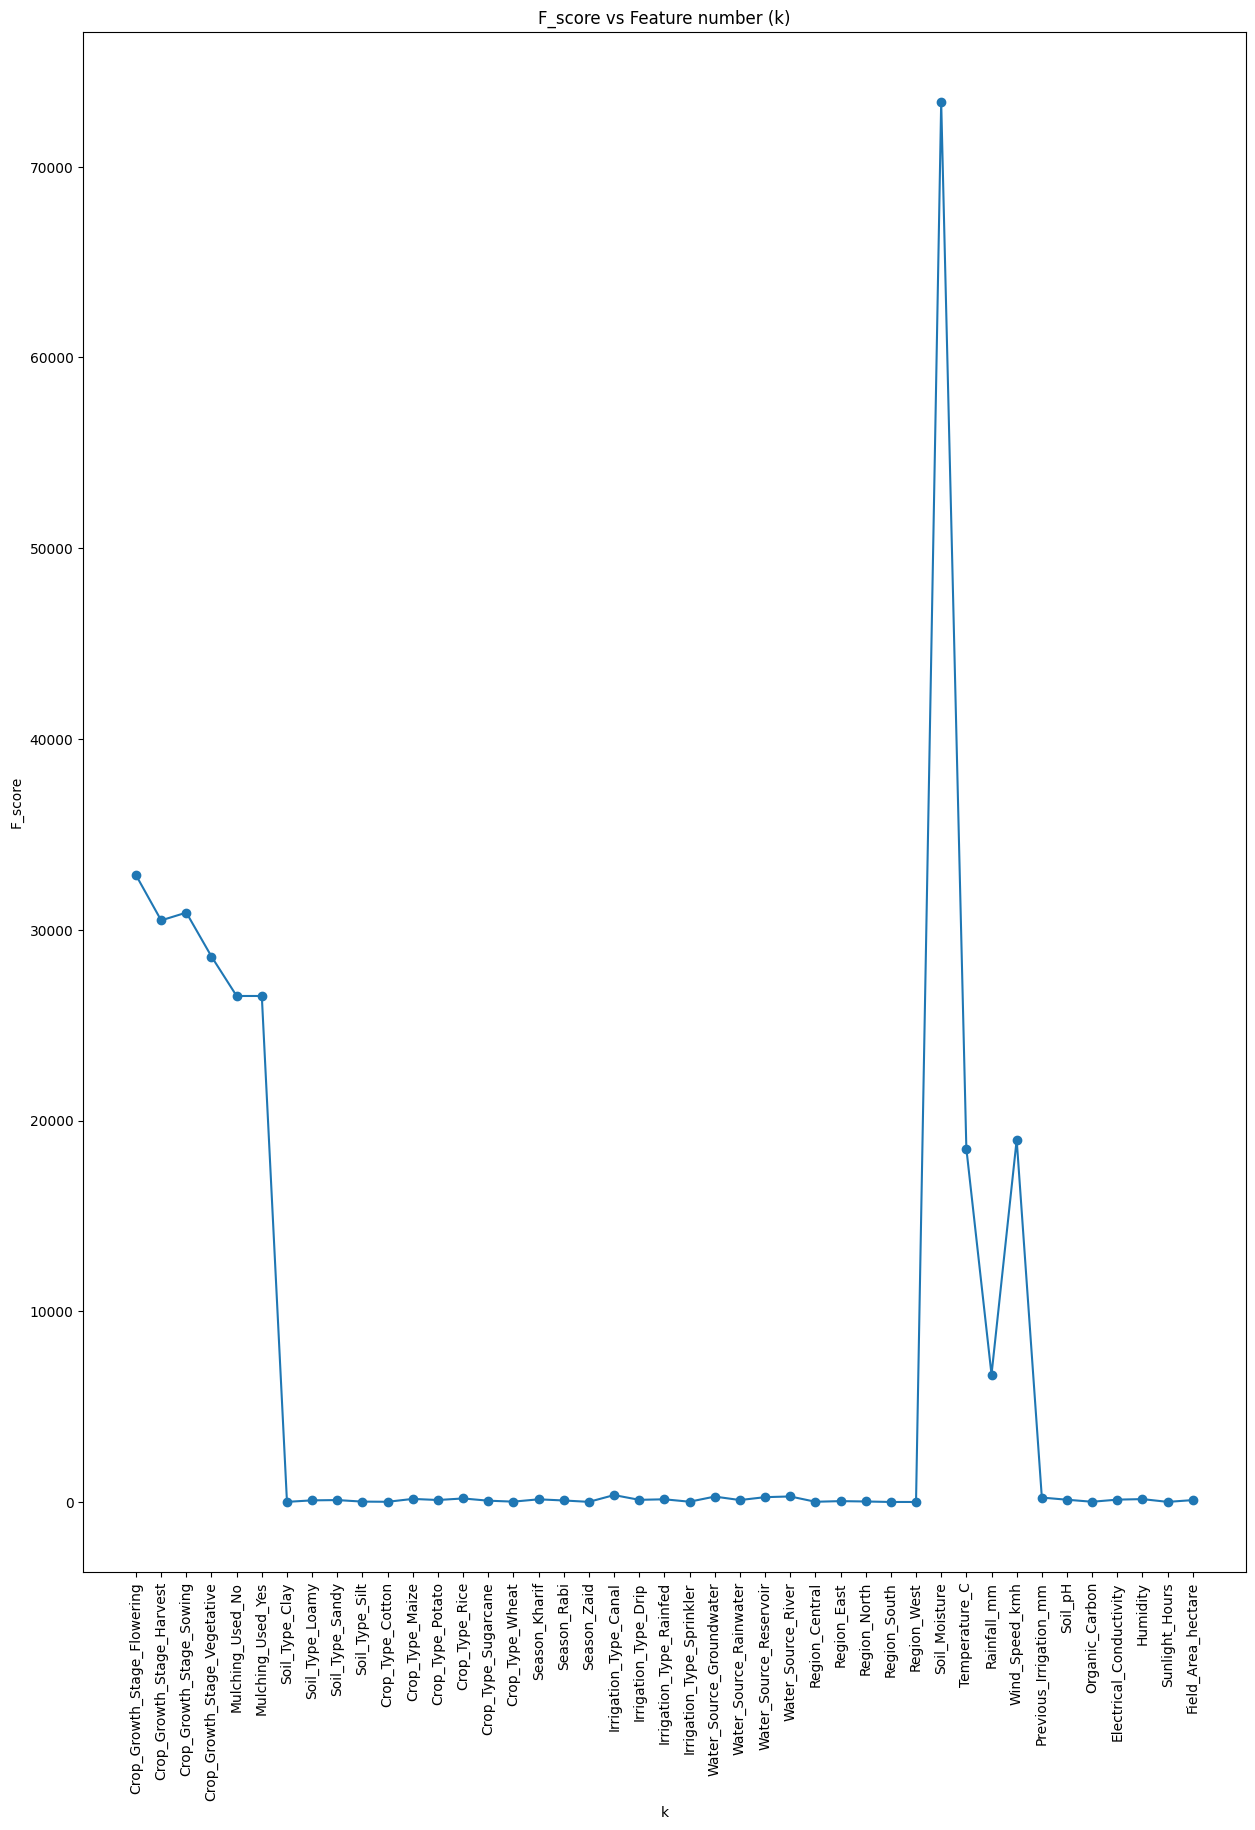

In [ ]:
ks = X_train_full.shape[1]
selector = SelectKBest(f_classif, k=ks)
X_train_k = selector.fit_transform(X_train_full, y_train)
X_test_k  = selector.transform(X_test_full)

X_train_kbest = selector.fit_transform(X_train_full, y_train)
selected_mask = selector.get_support()
selected_columns = X_train_full.columns[selected_mask]
df_kbest = pd.DataFrame(X_train_kbest, columns=selected_columns)

# Print best columns
for x in range(0, 43, 1):
    if selector.scores_[x] > 1000:
        print(X_train_full.columns[x])

# Score di ogni feature
plt.figure(figsize=(15,20))
plt.plot(range(0,ks, 1), selector.scores_, marker='o')
plt.xlabel("k")
plt.xticks(range(len(X_train_full.columns)), X_train_full.columns, rotation=90)
plt.ylabel("F_score")
plt.title("F_score vs Feature number (k)")
plt.show()

kbest_columns = selector.get_feature_names_out()
'''
kbest_columns = ['Crop_Growth_Stage', 'Mulching_Used', 'Soil_Moisture',
       'Temperature_C', 'Rainfall_mm', 'Wind_Speed_kmh']
'''
X_train_kbest = pd.DataFrame(X_train_full, columns=kbest_columns)
X_test_kbest = pd.DataFrame(X_test_full, columns=kbest_columns)


### 5) Model selection
N.B. Uncomment the first line replacing the second line to inspect all models

In [ ]:
#model_lbls = ["dt", "nb", "lr", "perc", "linsvc", "sgd", "adb", "rf", "lgbm"]
model_lbls = ["dt"]

models ={
    'nb': {'name': 'Gaussian Naive Bayes',
           'estimator': GaussianNB(),
           'param': [{'var_smoothing': [10**exp for exp in range(-3,-10,-1)]}]
        },
    'lr': {'name': 'Logistic Regression',
           'estimator': LogisticRegression(solver='saga',max_iter=1000,tol=1e-2,n_jobs=-1),
           'param': [{'C': [0.1, 1],'penalty': ['l2'],'class_weight': [None]}]
        },

    'perc': {
        'name': 'Perceptron',
        'estimator': Perceptron(),
        'param': [{'penalty': [None, 'l2', 'l1'],'alpha': [1e-4, 1e-3, 1e-2],'class_weight': [None, 'balanced']}]
        },

    'linsvc': {
        'name': 'Linear SVC',
        'estimator': LinearSVC(),
        'param': [{'C': [0.1, 1, 10],'class_weight': [None, 'balanced']}]
        },

    'sgd': {
        'name': 'SGD Classifier',
        'estimator': SGDClassifier(),
        'param': [{'loss': ['hinge', 'log_loss'],
                   'alpha': [1e-4, 1e-3, 1e-2],
                   'class_weight': [None, 'balanced']}]
        },
    'adb':{'name': 'AdaBoost           ',
           'estimator': AdaBoostClassifier(random_state=random_state),
           'param': [{'n_estimators':[*range(20,50,10)]
                     ,'learning_rate':[1.15,1.2,1,25]}]
          },
    'rf': {'name': 'Random forest',
           'estimator': RandomForestClassifier(random_state=random_state),
           'param': [{
                'bootstrap': [False],
                'class_weight': ['balanced'], 
                'criterion': ['gini'], 
                'max_depth': [9], 
                'max_leaf_nodes': [None], 
                'n_estimators': [100]
                }]
          },
    'dt': {'name': 'Decision Tree',
            'estimator': DecisionTreeClassifier(random_state=random_state),
            'param': [{
                    'max_depth': [9],   
                    'criterion': ['gini'],   
                    'splitter': ['best'],     
                    'max_features': [None, 'log-loss'],    
                    'class_weight': ['balanced'],
                    'min_impurity_decrease': [0.0], 
                    'min_samples_leaf': [2], 
                    'min_samples_split': [5]
                    }]
                      
      },
    'lgbm': {'name': 'LightGBM',
            'estimator': LGBMClassifier(random_state=random_state,class_weight='balanced',n_jobs=-1),
            'param': [{
                    'class_weight' : ['balanced'],
                    'boosting_type' : ['gbdt'],
                    'max_depth': [9],           
                    'learning_rate': [0.05],
                    'n_estimators': [300],
                    'reg_alpha' : [0.1],   # L1
                    'reg_lambda': [1.0],  # L2
                    'scale_pos_weight' : [0.7] 
                    }]
      }
}

### 6) GridSearch and gaining results

In [ ]:
results = pd.DataFrame(columns=['scoring','model','balanced_accuracy','best_params'])
y_preds = []
clfs = []
print(model_lbls)
for m in model_lbls:
    clf = GridSearchCV(models[m]['estimator'], models[m]['param'], cv=5, scoring = 'balanced_accuracy')
    clf.fit(X_train_full, y_train)   
    clfs.append(clf)
    y_predicted_train = clf.best_estimator_.predict(X_train_full)
    balanced_train = balanced_accuracy_score(y_train, y_predicted_train, sample_weight=None, adjusted=False)
    print("The balanced accuracy on train set is {0:.3f}%".format(balanced_train * 100))
    y_predicted_test = clf.best_estimator_.predict(X_test_full)                  
    balanced_test = balanced_accuracy_score(y_test, y_predicted_test, sample_weight=None, adjusted=False)
    print("The balanced accuracy on test set is {0:.3f}%".format(balanced_test * 100))

    results.loc[len(results)] = ['balanced_accuracy',models[m]['name'],balanced_accuracy_score(y_train, y_predicted_train),clf.best_params_]

    

['dt']
The balanced accuracy on train set is 96.995%
The balanced accuracy on test set is 96.543%


### 7)Results and target classes distributions

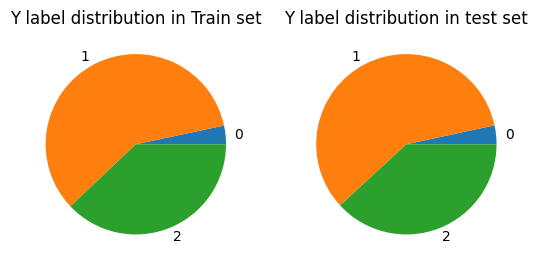

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 9, 'max_features': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'splitter': 'best'}


,scoring,model,balanced_accuracy,best_params
0,balanced_accuracy,Decision Tree,0.969945,"{'class_weight': 'balanced', 'criterion': 'gin..."


In [ ]:
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2)
ax1.pie(np.unique(y_train, return_counts=True)[1], labels=np.unique(y_train, return_counts=True)[0]);
ax1.set_title("Y label distribution in Train set")
ax2.pie(np.unique(y_test, return_counts=True)[1], labels=np.unique(y_test, return_counts=True)[0]);
ax2.set_title("Y label distribution in test set")
plt.show()

print(str(clf.best_params_))
results

### 8) Final insights: confusion matrix

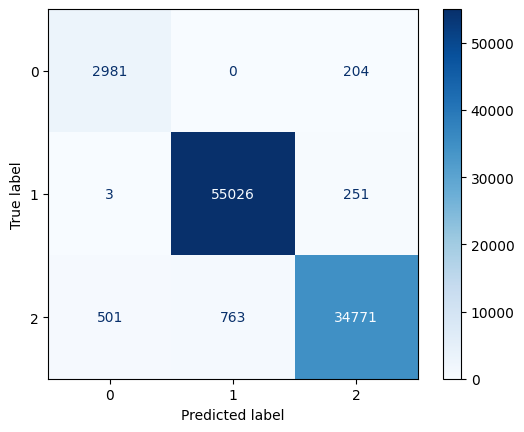

{'High': 0, 'Low': 1, 'Medium': 2}


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_predicted_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.show()

mapping = dict(zip(le.classes_, range(len(le.classes_))))

print(mapping)

### Kaggle submission
After training and testing

In [ ]:
url_test = './test.csv'
sep = ','
df_competition = pd.read_csv(url_test, header=0, sep=sep)
id_col = df_competition['id']

df_comp_ohe = pd.DataFrame(ohe.transform(df_competition[cols_to_one_hot_encode]), columns=ohe_cols, index=df_competition.index)
df_comp_qt = pd.DataFrame(df_competition[cols_to_transform], columns=cols_to_transform, index=df_competition.index)

df_final = pd.concat([df_comp_ohe, df_comp_qt], axis=1)
test_prediciton = clf.best_estimator_.predict(df_final)

col2 = le.inverse_transform(test_prediciton)
submission = pd.DataFrame({
    "id": id_col,
    "Irrigation_Need": col2
})
#submission.to_csv('./submission.csv',sep=',', header=True, index=False)
